# Embedding Space Visualization (t-SNE)

Loads the trained model, embeds the full test set, projects the 128-D embeddings to 2-D with t-SNE, and plots each digit cluster with a label.

In [7]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.manifold import TSNE

from dataset import MNISTDataset
from model import SiameseRIZZNet


## 1. Load the trained model

In [8]:
CHECKPOINT_PATH = "checkpoints/best_model.pt"
TEST_CSV_PATH = "/home/mahmoud-sayed/Desktop/ITI/Computer VIsion/Assignment 4/data/mnist_test.csv"

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

model = SiameseRIZZNet(128, 0.01).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint.get('epoch')} | val_loss={checkpoint.get('val_loss'):.4f}")


Using device: cpu
Loaded checkpoint from epoch 30 | val_loss=0.0020


## 2. Pass the full test set through the model and store embeddings

In [9]:
# Reuse MNISTDataset's CSV loading/parsing (same pixel columns, same "label" column),
# but bypass its pair/triplet sampling -- we want every test image exactly once, flat.
test_dataset = MNISTDataset(csv_path=TEST_CSV_PATH)
df = test_dataset.df

labels_all = df["label"].to_numpy()
pixels_all = df.drop(columns=["label"]).to_numpy(dtype=np.float32) / 255.0
images_all = torch.from_numpy(pixels_all.reshape(-1, 1, 28, 28))

print(f"Test set: {images_all.shape[0]} images")


Test set: 10000 images


In [10]:
@torch.no_grad()
def extract_all_embeddings(model, images, device, batch_size=512):
    model.eval()
    embeddings = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i + batch_size].to(device)
        emb = model(batch)
        embeddings.append(emb.cpu())
    return torch.cat(embeddings, dim=0).numpy()


embeddings_all = extract_all_embeddings(model, images_all, device)
print(f"Embeddings shape: {embeddings_all.shape}")  # (N, 128)

# Store everything keyed for easy lookup / reuse later
embedding_store = {
    "embeddings": embeddings_all,   # (N, 128) float32
    "labels": labels_all,           # (N,) int, digit 0-9
}

# Also group by digit, handy if you want per-class stats (mean embedding, spread, etc.)
embeddings_by_digit = {
    digit: embeddings_all[labels_all == digit]
    for digit in range(10)
}


Embeddings shape: (10000, 128)


## 3. t-SNE: 128-D -> 2-D


In [11]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
)

embeddings_2d = tsne.fit_transform(embedding_store["embeddings"])
print(f"2D embeddings shape: {embeddings_2d.shape}")

2D embeddings shape: (10000, 2)


## 4. Interactive 3D plot, colored + labeled by digit cluster


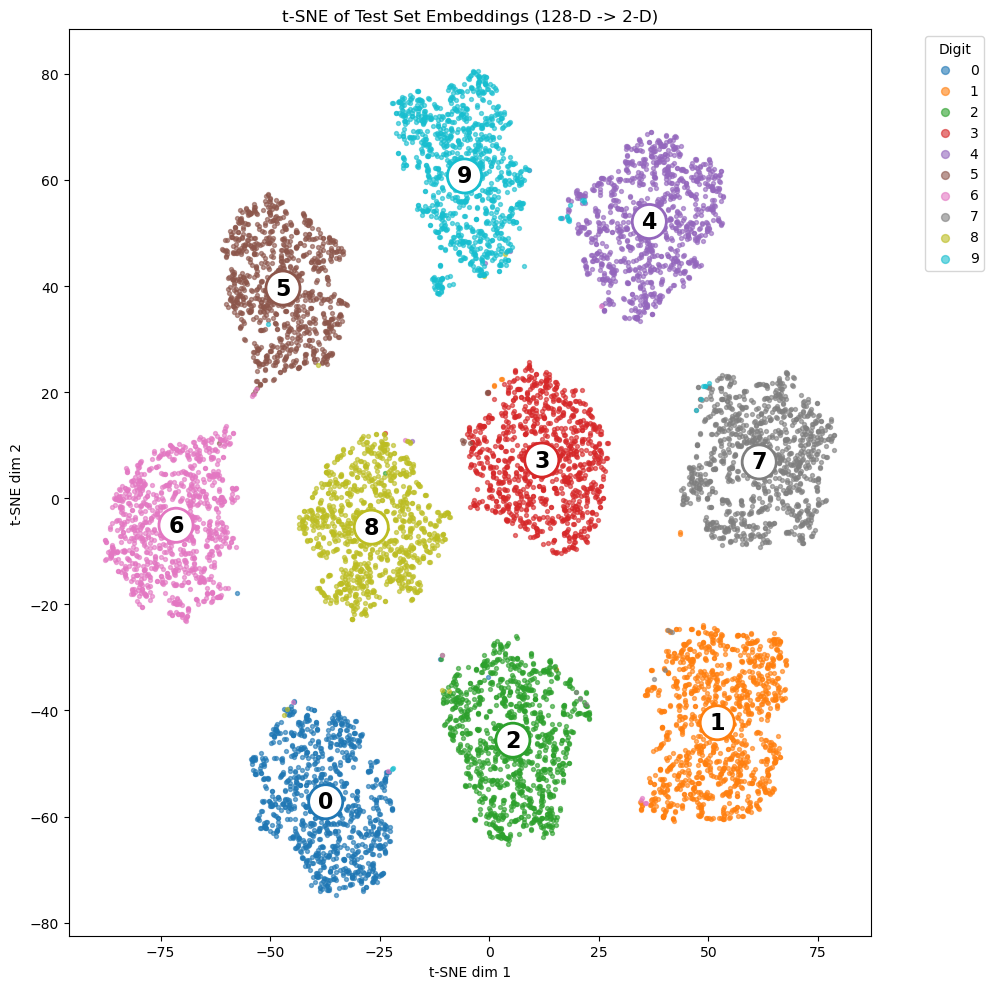

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

cmap = plt.get_cmap("tab10")
labels = embedding_store["labels"]

for digit in range(10):
    mask = labels == digit
    points = embeddings_2d[mask]
    ax.scatter(
        points[:, 0], points[:, 1],
        s=8, alpha=0.6,
        color=cmap(digit),
        label=str(digit),
    )

    # Label each cluster at its centroid
    centroid = points.mean(axis=0)
    ax.text(
        centroid[0], centroid[1], str(digit),
        fontsize=16, fontweight="bold",
        ha="center", va="center",
        color="black",
        bbox=dict(boxstyle="circle,pad=0.25", facecolor="white", edgecolor=cmap(digit), linewidth=2),
    )

ax.set_title("t-SNE of Test Set Embeddings [Triplet] (128-D -> 2-D)")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(title="Digit", loc="upper right", markerscale=2, bbox_to_anchor=(1.15, 1.0))
plt.tight_layout()
plt.show()

## 5. t-SNE: 128-D -> 3-D


In [13]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
)

embeddings_3d = tsne.fit_transform(embedding_store["embeddings"])
print(f"3D embeddings shape: {embeddings_3d.shape}")


3D embeddings shape: (10000, 3)


## 6. Interactive 3D plot, colored + labeled by digit cluster


In [14]:
cmap = plt.get_cmap("tab10")
labels = embedding_store["labels"]

def rgb_string(rgba):
    r, g, b, _ = rgba
    return f"rgb({int(r * 255)},{int(g * 255)},{int(b * 255)})"

fig = go.Figure()

for digit in range(10):
    mask = labels == digit
    points = embeddings_3d[mask]
    color = rgb_string(cmap(digit))

    # Point cloud for this digit
    fig.add_trace(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode="markers",
        marker=dict(size=3, color=color, opacity=0.6),
        name=str(digit),
        hovertemplate=f"digit {digit}<extra></extra>",
    ))

    # Bold cluster label floating at the centroid
    centroid = points.mean(axis=0)
    fig.add_trace(go.Scatter3d(
        x=[centroid[0]], y=[centroid[1]], z=[centroid[2]],
        mode="text",
        text=[str(digit)],
        textfont=dict(size=22, color="black"),
        showlegend=False,
        hoverinfo="skip",
    ))

fig.update_layout(
    title="t-SNE of Test Set Embeddings [Triplet] (128-D -> 3-D)",
    scene=dict(
        xaxis_title="t-SNE dim 1",
        yaxis_title="t-SNE dim 2",
        zaxis_title="t-SNE dim 3",
    ),
    legend_title="Digit",
    width=950,
    height=800,
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()


In [16]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
)

embeddings_umap_2d = reducer.fit_transform(embedding_store["embeddings"])
print(f"2D embeddings shape: {embeddings_umap_2d.shape}")

/home/mahmoud-sayed/miniconda3/envs/mainenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

/home/mahmoud-sayed/miniconda3/envs/mainenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



2D embeddings shape: (10000, 2)


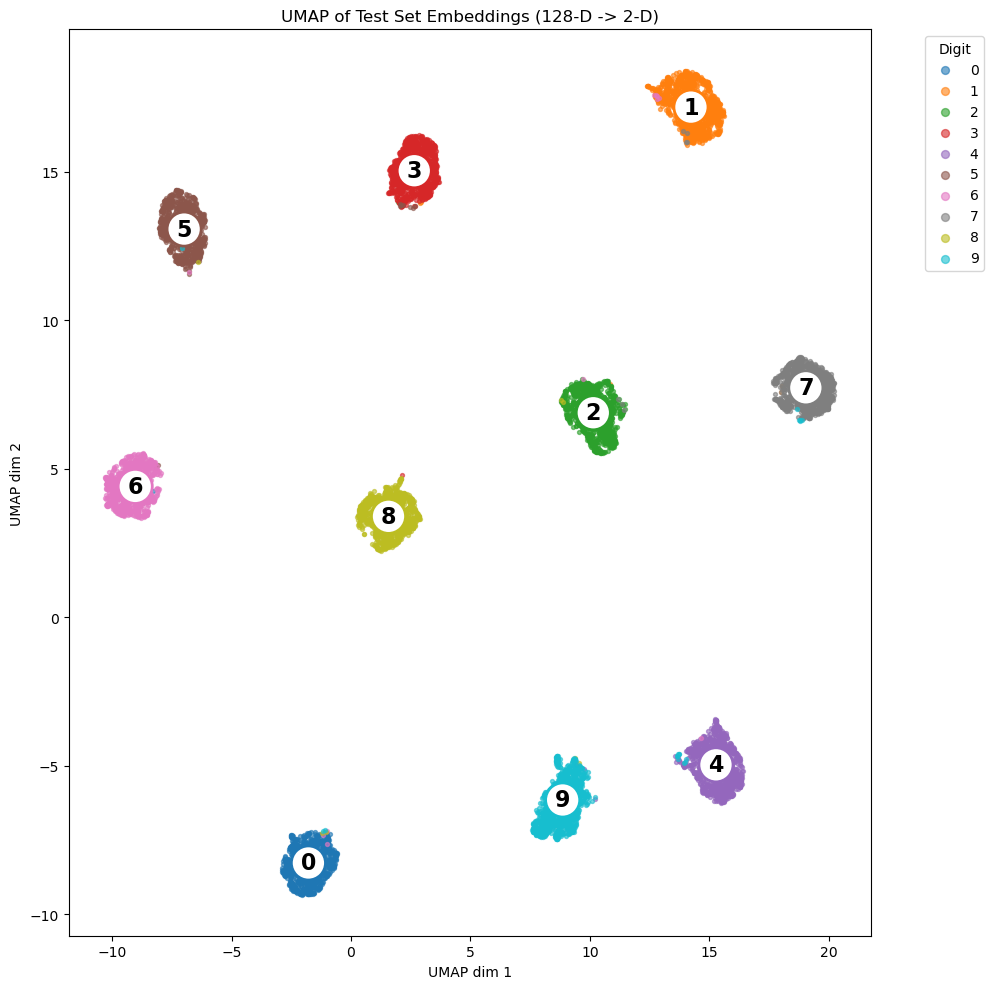

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

cmap = plt.get_cmap("tab10")
labels = embedding_store["labels"]

for digit in range(10):
    mask = labels == digit
    points = embeddings_umap_2d[mask]
    ax.scatter(
        points[:, 0], points[:, 1],
        s=8, alpha=0.6,
        color=cmap(digit),
        label=str(digit),
    )

    centroid = points.mean(axis=0)
    ax.text(
        centroid[0], centroid[1], str(digit),
        fontsize=16, fontweight="bold",
        ha="center", va="center",
        color="black",
        bbox=dict(boxstyle="circle,pad=0.25", facecolor="white", edgecolor=cmap(digit), linewidth=2),
    )

ax.set_title("UMAP of Test Set Embeddings [Triplet] (128-D -> 2-D)")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.legend(title="Digit", loc="upper right", markerscale=2, bbox_to_anchor=(1.15, 1.0))
plt.tight_layout()
plt.show()

In [18]:
# pip install umap-learn
import umap

reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
)

embeddings_umap_3d = reducer.fit_transform(embedding_store["embeddings"])
print(f"3D embeddings shape: {embeddings_umap_3d.shape}")

/home/mahmoud-sayed/miniconda3/envs/mainenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



3D embeddings shape: (10000, 3)


In [ ]:
import plotly.graph_objects as go

cmap = plt.get_cmap("tab10")
labels = embedding_store["labels"]

def rgb_string(rgba):
    r, g, b, _ = rgba
    return f"rgb({int(r * 255)},{int(g * 255)},{int(b * 255)})"

fig = go.Figure()

for digit in range(10):
    mask = labels == digit
    points = embeddings_umap_3d[mask]
    color = rgb_string(cmap(digit))

    fig.add_trace(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode="markers",
        marker=dict(size=3, color=color, opacity=0.6),
        name=str(digit),
        hovertemplate=f"digit {digit}<extra></extra>",
    ))

    centroid = points.mean(axis=0)
    fig.add_trace(go.Scatter3d(
        x=[centroid[0]], y=[centroid[1]], z=[centroid[2]],
        mode="text",
        text=[str(digit)],
        textfont=dict(size=22, color="black"),
        showlegend=False,
        hoverinfo="skip",
    ))

fig.update_layout(
    title="UMAP of Test Set Embeddings [Triplet] (128-D -> 3-D)",
    scene=dict(
        xaxis_title="UMAP dim 1",
        yaxis_title="UMAP dim 2",
        zaxis_title="UMAP dim 3",
    ),
    legend_title="Digit",
    width=950,
    height=800,
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()